# Tabular regression with `LanguageModelRegressor`

The shared fine-tune (see `00-intro.ipynb`) lets the model condition any column on the others. For
regression the target is a number, and the model defines a distribution $p(y \mid x)$ over the
*text* of that number. The predictor that minimizes squared error is the **conditional mean**
$\mathbb{E}[y \mid x]$, which we read off the fitted model below.

distilgpt2 is a tiny base model; the bar to beat is the **baseline that always predicts the training
mean** $\bar{y}$, whose error we print alongside the model's.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

from sklm import (
    DiscretizationConfig,
    GenerationConfig,
    LanguageModelRegressor,
    TrainingConfig,
)

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

## Data

The Auto MPG dataset: seven attributes of late-1970s cars — number of cylinders, engine
displacement, horsepower, weight, acceleration, model year, and the region of `origin` as a
string — and the fuel efficiency in miles per gallon to predict. The numbers stay in their natural
units so the serialized rows are human-readable. (`seaborn` fetches the table once and caches it
locally.)

In [11]:
mpg = sns.load_dataset("mpg").dropna()
features = [
    "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin",
]
X = mpg[features].round(1)
y = mpg["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
260,6,225.0,110.0,3620,18.7,78,usa
184,4,140.0,92.0,2572,14.9,76,usa
174,6,171.0,97.0,2984,14.5,75,usa
64,8,318.0,150.0,4135,13.5,72,usa
344,4,86.0,64.0,1875,16.4,81,usa


## Fine-tuning

`loss_on_target_only=True` restricts the training loss to the target tokens, so optimization focuses
on predicting mpg rather than re-modelling the feature text. `batch_size` packs many serialized rows
into each step and is the main lever on wall-clock time; `augmentation_factor` and `epochs`
*multiply* to set how many permuted views of the table the model sees in total.

In [12]:
reg = LanguageModelRegressor(
    model="gabfssilva/distilgpt2",
    backend="mlx",
    precision="fp32",
    training=TrainingConfig(
        epochs=3,
        augmentation_factor=6,
        batch_size=16,
        learning_rate=1e-4,
        lr_scheduler="linear",
        warmup_ratio=0.03,
        loss_on_target_only=True,
    ),
    random_state=SEED,
).fit(X_train, y_train)

## Sampling — the default decoder

With no `discretization` set, `predict` uses the sampling decoder; pass
`generation=GenerationConfig(n_samples=...)` and it averages that many draws per row. Mean absolute
error (MAE) and root mean squared error (RMSE) are in the target's units (RMSE penalizes large misses
more); the coefficient of determination

$$ R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2} $$

is $1$ for a perfect fit, $0$ for the mean baseline, and $<0$ when the model does *worse* than
predicting $\bar{y}$. The `above max mpg` count flags any draw that leaked out of the target's
range — the sampling decoder's one failure mode.

In [13]:
pred_sampled = reg.predict(X_test, generation=GenerationConfig(n_samples=20, temperature=0.7))
baseline = np.full(len(y_test), y_train.mean())
leaked = int((pred_sampled > y_train.max()).sum())

print(f"sampled MAE : {mean_absolute_error(y_test, pred_sampled):6.2f}")
print(f"sampled RMSE: {root_mean_squared_error(y_test, pred_sampled):6.2f}")
print(f"sampled R2  : {r2_score(y_test, pred_sampled):6.3f}")
print(f"mean    MAE : {mean_absolute_error(y_test, baseline):6.2f}  (baseline: predict the training mean)")
print(f"draws above max mpg ({y_train.max():.0f}): {leaked} / {len(y_test)}")

HTML(value='')

sampled MAE :   2.32
sampled RMSE:   3.10
sampled R2  :  0.812
mean    MAE :   5.88  (baseline: predict the training mean)
draws above max mpg (47): 0 / 79


## Predicted vs. true (sampling)

Points on the dashed line $\hat{y} = y$ are perfect predictions; vertical distance from it is the
error.

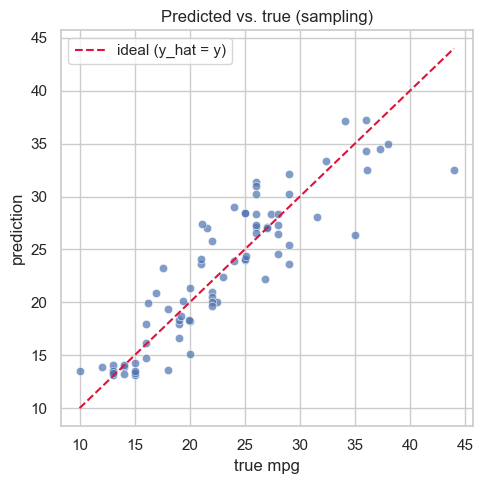

In [14]:
lo = float(min(y_test.min(), pred_sampled.min()))
hi = float(max(y_test.max(), pred_sampled.max()))

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=y_test, y=pred_sampled, ax=ax, alpha=0.7)
ax.plot([lo, hi], [lo, hi], color="crimson", linestyle="--", label="ideal (y_hat = y)")
ax.set_xlabel("true mpg")
ax.set_ylabel("prediction")
ax.set_title("Predicted vs. true (sampling)")
ax.legend()
plt.tight_layout()
plt.show()

## Residuals (sampling)

Residuals $\hat{y} - y$ should scatter around zero with no trend. A slope or fan shape signals
systematic bias the model is missing.

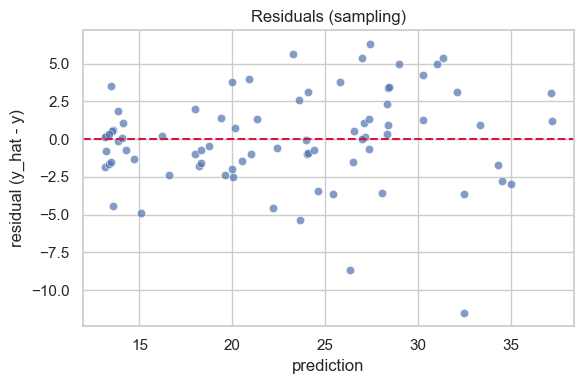

In [15]:
resid_sampled = pred_sampled - y_test.to_numpy()

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x=pred_sampled, y=resid_sampled, ax=ax, alpha=0.7)
ax.axhline(0, color="crimson", linestyle="--")
ax.set_xlabel("prediction")
ax.set_ylabel("residual (y_hat - y)")
ax.set_title("Residuals (sampling)")
plt.tight_layout()
plt.show()

## Scoring — a small lift from discretizing

Depending on the data you can often squeeze out a bit more by **discretizing**: pass
`discretization=DiscretizationConfig(bins=1.0)` to `predict` to opt into the scoring decoder. It is a
per-call override on the same fitted weights — a predict-time switch, no re-fit — that ranks the
observed target values by likelihood and averages them, so the estimate is bounded to values the
target actually took and never leaves their range. The same two plots follow, now on the discretized
predictions.

In [16]:
pred_scored = reg.predict(X_test, discretization=DiscretizationConfig(bins=1.0))

print(f"scored  R2: {r2_score(y_test, pred_scored):6.3f}   MAE: {mean_absolute_error(y_test, pred_scored):5.2f}")
print(f"sampled R2: {r2_score(y_test, pred_sampled):6.3f}   MAE: {mean_absolute_error(y_test, pred_sampled):5.2f}")

HTML(value='')

scored  R2:  0.822   MAE:  2.30
sampled R2:  0.812   MAE:  2.32


## Predicted vs. true (scoring)

Points on the dashed line $\hat{y} = y$ are perfect predictions; vertical distance from it is the
error.

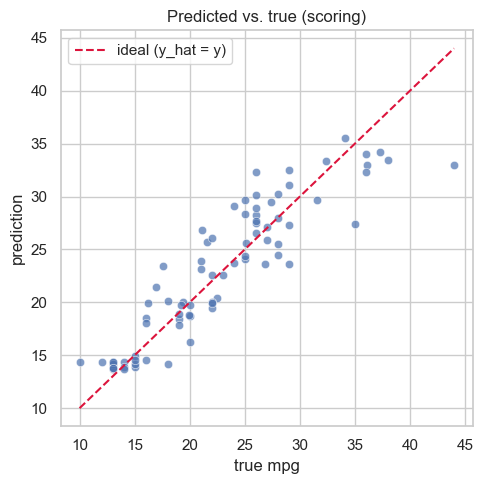

In [17]:
lo = float(min(y_test.min(), pred_scored.min()))
hi = float(max(y_test.max(), pred_scored.max()))

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=y_test, y=pred_scored, ax=ax, alpha=0.7)
ax.plot([lo, hi], [lo, hi], color="crimson", linestyle="--", label="ideal (y_hat = y)")
ax.set_xlabel("true mpg")
ax.set_ylabel("prediction")
ax.set_title("Predicted vs. true (scoring)")
ax.legend()
plt.tight_layout()
plt.show()

## Residuals (scoring)

Residuals $\hat{y} - y$ should scatter around zero with no trend. A slope or fan shape signals
systematic bias the model is missing.

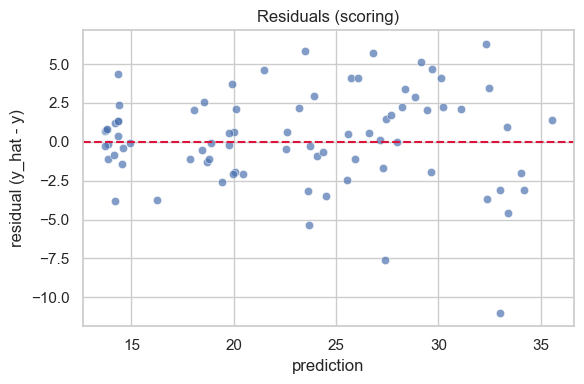

In [18]:
resid = pred_scored - y_test.to_numpy()

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x=pred_scored, y=resid, ax=ax, alpha=0.7)
ax.axhline(0, color="crimson", linestyle="--")
ax.set_xlabel("prediction")
ax.set_ylabel("residual (y_hat - y)")
ax.set_title("Residuals (scoring)")
plt.tight_layout()
plt.show()